# 11｜TinyViT Attention Rollout 与遮挡验证

上一课查看了单个 Encoder Block 的 Raw Attention，它只能回答“这一层怎样分配注意力”。但最终 CLS 已经经过 6 层更新，还通过每层残差连接保留了旧信息。

本课使用 **Attention Rollout** 把多层注意力路径组合起来，再用 patch 遮挡实验检查高关注区域是否更影响模型预测。

## 1. 本课目标

1. 理解为什么最后一层 Attention 不等于完整信息路径；
2. 理解 Rollout 为什么要加入单位矩阵；
3. 按正确顺序累乘 6 层注意力矩阵；
4. 对比 Raw Attention 与 Attention Rollout；
5. 遮挡 Rollout 得分最高和最低的 patches；
6. 区分可视化线索与因果证据。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import torch.nn.functional as F
from IPython.display import display
from torchvision import datasets, transforms

from vit import BEST_MODEL_PATH, DATA_ROOT, TinyViT
from vit.data import CIFAR10_MEAN, CIFAR10_STD

get_ipython().run_line_magic("matplotlib", "inline")
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False
device = torch.device("cpu")
print("计算设备：", device)

计算设备： cpu


## 2. 为什么不能只看最后一层

假设最后一层中 CLS 关注 patch A，这并不意味着 A 的信息只来自图片中的 A。进入最后一层以前，patch A 已经在前 5 层读取过其他 token。

因此：

- Raw Attention 描述**当前一层的直接连接**；
- Attention Rollout 尝试描述**跨层累计连接**。

如果第 1 层关系为 $A_1$，第 2 层关系为 $A_2$，两层后的累计路径近似为：

$$A_{joint}^{(2)} = A_2 A_1$$

矩阵顺序不能颠倒：第 2 层读取的是第 1 层已经混合后的 token。

## 3. 为什么要加入单位矩阵

我们的注意力子层不是只有 $A V$，而是包含残差连接：

$$x' = x + \operatorname{Attention}(x)$$

单位矩阵 $I$ 表示每个 token 直接保留自身信息。Rollout 常用下面的近似：

$$\tilde A_l = \operatorname{RowNormalize}(A_l + I)$$

然后从浅到深累计：

$$R_l = \tilde A_l R_{l-1}, \qquad R_0 = I$$

这里先平均 4 个 head，再加入单位矩阵。Rollout 是对真实网络信息流的简化，不会包含 MLP、Value 内容和非线性变化。

In [2]:
checkpoint = torch.load(Path(BEST_MODEL_PATH), map_location=device, weights_only=True)
model = TinyViT().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_dataset = datasets.CIFAR10(
    root=DATA_ROOT, train=False, transform=evaluation_transform, download=False
)
sample_indices = [0, 1, 2, 3]
samples = [test_dataset[index] for index in sample_indices]
images = torch.stack([sample[0] for sample in samples]).to(device)
labels = torch.tensor([sample[1] for sample in samples], device=device)

mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
display_images = (images.cpu() * std + mean).clamp(0, 1)

print("checkpoint epoch：", checkpoint["epoch"])
print(f"checkpoint 验证准确率：{checkpoint['validation_accuracy'] * 100:.2f}%")
print("输入 shape：", tuple(images.shape))

checkpoint epoch： 278
checkpoint 验证准确率：89.74%
输入 shape： (4, 3, 32, 32)


## 4. 提取每一层的多头注意力

和上一课一样，在 notebook 内按原结构重放 forward，并令 MHA 返回每个 head 的权重。最后用原模型输出进行一致性检查，确保提取过程没有改变计算结果。

In [3]:
def forward_with_attention(model, images):
    """返回 logits 与 BxLxHxNxN 的注意力权重。"""
    x = model.input_embedding(images)
    attention_per_layer = []
    for block in model.encoder.blocks:
        sublayer = block.attention_sub_layer
        normalized = sublayer.layer_norm1(x)
        output, weights = sublayer.multi_head_attention(
            normalized, normalized, normalized,
            need_weights=True, average_attn_weights=False,
        )
        x = x + sublayer.dropout(output)
        x = block.mlp_sub_layer(x)
        attention_per_layer.append(weights)
    x = model.encoder.final_layer_norm(x)
    logits = model.classification_head(x[:, 0])
    return logits, torch.stack(attention_per_layer, dim=1)

with torch.inference_mode():
    normal_logits = model(images)
    logits, attention = forward_with_attention(model, images)
predictions = logits.argmax(dim=1)

print("attention shape：", tuple(attention.shape))
print("forward 最大差值：", (normal_logits - logits).abs().max().item())
for index, true_label, predicted_label in zip(sample_indices, labels, predictions):
    print(
        f"index={index} 真实={test_dataset.classes[true_label.item()]:10s} "
        f"预测={test_dataset.classes[predicted_label.item()]:10s}"
    )

assert attention.shape == (4, 6, 4, 65, 65)
assert torch.allclose(normal_logits, logits, atol=1e-5, rtol=1e-5)

attention shape： (4, 6, 4, 65, 65)
forward 最大差值： 0.0
index=0 真实=cat        预测=cat       
index=1 真实=ship       预测=ship      
index=2 真实=ship       预测=ship      
index=3 真实=airplane   预测=airplane  


## 5. 实现 Attention Rollout

函数返回每一层结束后的累计矩阵，shape 为 `B x 6 x 65 x 65`。保留逐层结果，可以观察路径怎样从第 1 层逐渐累积到第 6 层。

In [4]:
def attention_rollout(attention):
    """将 BxLxHxNxN 注意力转换为 BxLxNxN 累计路径。"""
    fused = attention.mean(dim=2)  # 平均多个 head：B x L x N x N
    batch_size, num_layers, num_tokens, _ = fused.shape
    identity = torch.eye(num_tokens, device=fused.device).unsqueeze(0)
    augmented = fused + identity.unsqueeze(1)
    augmented = augmented / augmented.sum(dim=-1, keepdim=True)

    joint = identity.expand(batch_size, -1, -1).clone()
    rollout_per_layer = []
    for layer_index in range(num_layers):
        joint = augmented[:, layer_index] @ joint
        rollout_per_layer.append(joint)
    return torch.stack(rollout_per_layer, dim=1)

rollout = attention_rollout(attention)
print("rollout shape：", tuple(rollout.shape))
print("最终累计矩阵每行和：", rollout[0, -1, 0].sum().item())

assert rollout.shape == (4, 6, 65, 65)
assert torch.allclose(rollout.sum(dim=-1), torch.ones_like(rollout.sum(dim=-1)), atol=1e-5)

rollout shape： (4, 6, 65, 65)
最终累计矩阵每行和： 1.0000001192092896


## 6. Raw Attention 与 Rollout 对比

- Raw Attention：最后一层 CLS 直接关注哪些 patches；
- Rollout：加入残差并组合 6 层以后，最终 CLS 与输入 patches 的累计连接。

两张图不同是正常现象，因为回答的问题不同。

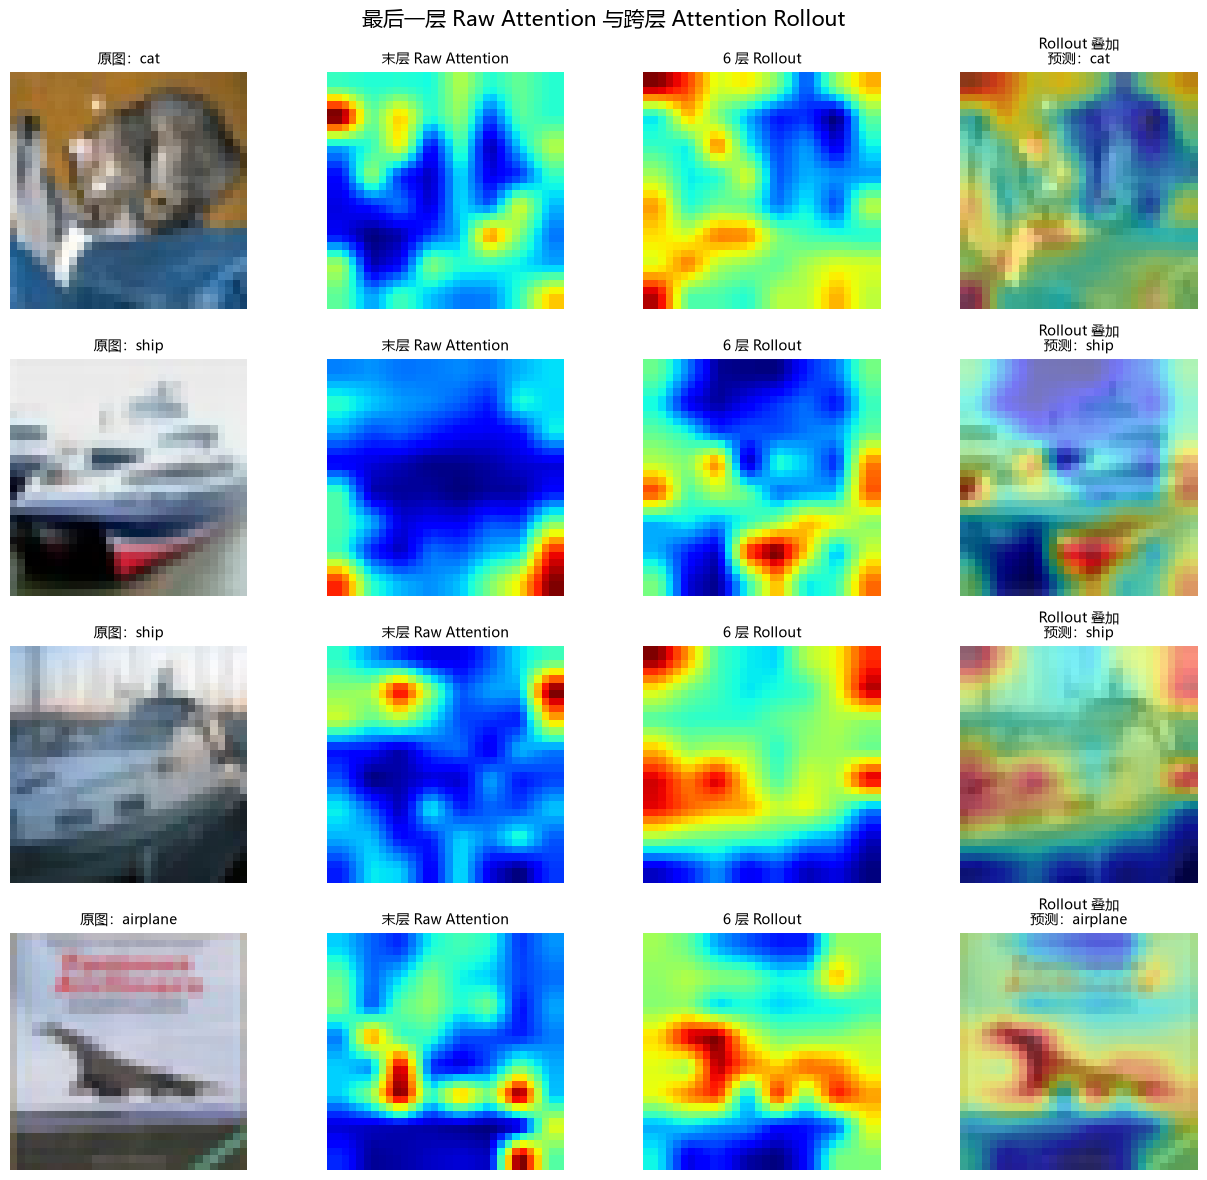

In [5]:
def resize_and_normalize(scores):
    """将 Bx64 分数还原成归一化的 Bx32x32 热力图。"""
    maps = scores.reshape(-1, 1, 8, 8)
    maps = F.interpolate(maps, (32, 32), mode="bilinear", align_corners=False)[:, 0]
    minimum = maps.flatten(1).min(dim=1).values[:, None, None]
    maximum = maps.flatten(1).max(dim=1).values[:, None, None]
    return ((maps - minimum) / (maximum - minimum + 1e-8)).cpu()

raw_scores = attention[:, -1, :, 0, 1:].mean(dim=1)
rollout_scores = rollout[:, -1, 0, 1:]
raw_maps = resize_and_normalize(raw_scores)
rollout_maps = resize_and_normalize(rollout_scores)

fig, axes = plt.subplots(4, 4, figsize=(13, 12))
for row in range(4):
    image = display_images[row].permute(1, 2, 0)
    panels = [image, raw_maps[row], rollout_maps[row], image]
    titles = [
        f"原图：{test_dataset.classes[labels[row].item()]}",
        "末层 Raw Attention",
        "6 层 Rollout",
        f"Rollout 叠加\n预测：{test_dataset.classes[predictions[row].item()]}",
    ]
    for column in range(4):
        axes[row, column].imshow(panels[column], cmap="jet" if column in (1, 2) else None)
        if column == 3:
            axes[row, column].imshow(rollout_maps[row], cmap="jet", alpha=0.5)
        axes[row, column].set_title(titles[column], fontsize=10)
        axes[row, column].axis("off")
plt.suptitle("最后一层 Raw Attention 与跨层 Attention Rollout", fontsize=15)
plt.tight_layout()
display(fig)
plt.close(fig)

## 7. 累计路径怎样逐层形成

下面固定第 1 张图片，依次显示经过 1～6 个 Blocks 后的 Rollout。注意，这不是每层独立的 Attention，而是从第一层开始不断累积的结果。

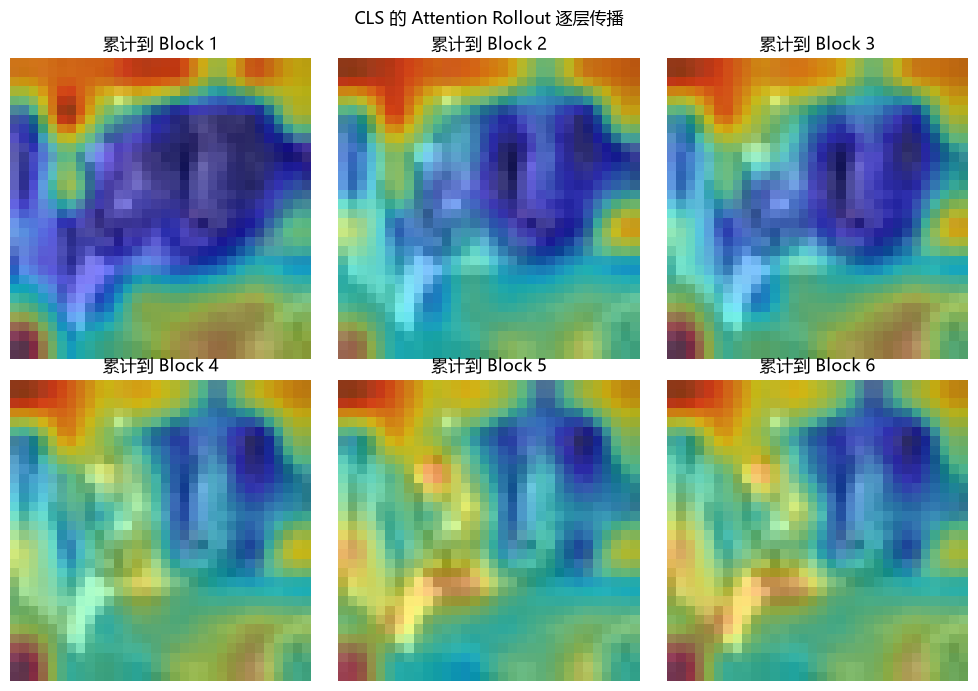

In [6]:
progression_scores = rollout[0, :, 0, 1:]
progression_maps = resize_and_normalize(progression_scores)
image = display_images[0].permute(1, 2, 0)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for layer_index, axis in enumerate(axes.flat):
    axis.imshow(image)
    axis.imshow(progression_maps[layer_index], cmap="jet", alpha=0.5)
    axis.set_title(f"累计到 Block {layer_index + 1}")
    axis.axis("off")
plt.suptitle("CLS 的 Attention Rollout 逐层传播")
plt.tight_layout()
display(fig)
plt.close(fig)

## 8. 遮挡验证：移除高分 patch 与低分 patch

Rollout 仍然只是一种结构近似。现在真正修改输入：

- 找出 Rollout 得分最高的 8 个 patches；
- 找出得分最低的 8 个 patches；
- 分别把这些区域设为标准化后的 0，即接近数据集平均颜色；
- 观察模型对**原预测类别**的置信度下降多少。

若遮挡高分区域造成更大下降，说明 Rollout 与模型响应具有一定一致性；若没有，也不能简单判定 Rollout 错误，因为遮挡会制造新输入，patch 之间还存在冗余信息。

原类别置信度变化（正数表示下降）：
cat        原始=0.938  遮挡高分=0.960 (下降 -0.022)  遮挡低分=0.963 (下降 -0.025)
ship       原始=0.950  遮挡高分=0.947 (下降 +0.004)  遮挡低分=0.955 (下降 -0.004)
ship       原始=0.930  遮挡高分=0.956 (下降 -0.026)  遮挡低分=0.957 (下降 -0.028)
airplane   原始=0.787  遮挡高分=0.757 (下降 +0.030)  遮挡低分=0.855 (下降 -0.068)

平均下降：高分 patches=-0.004，低分 patches=-0.031


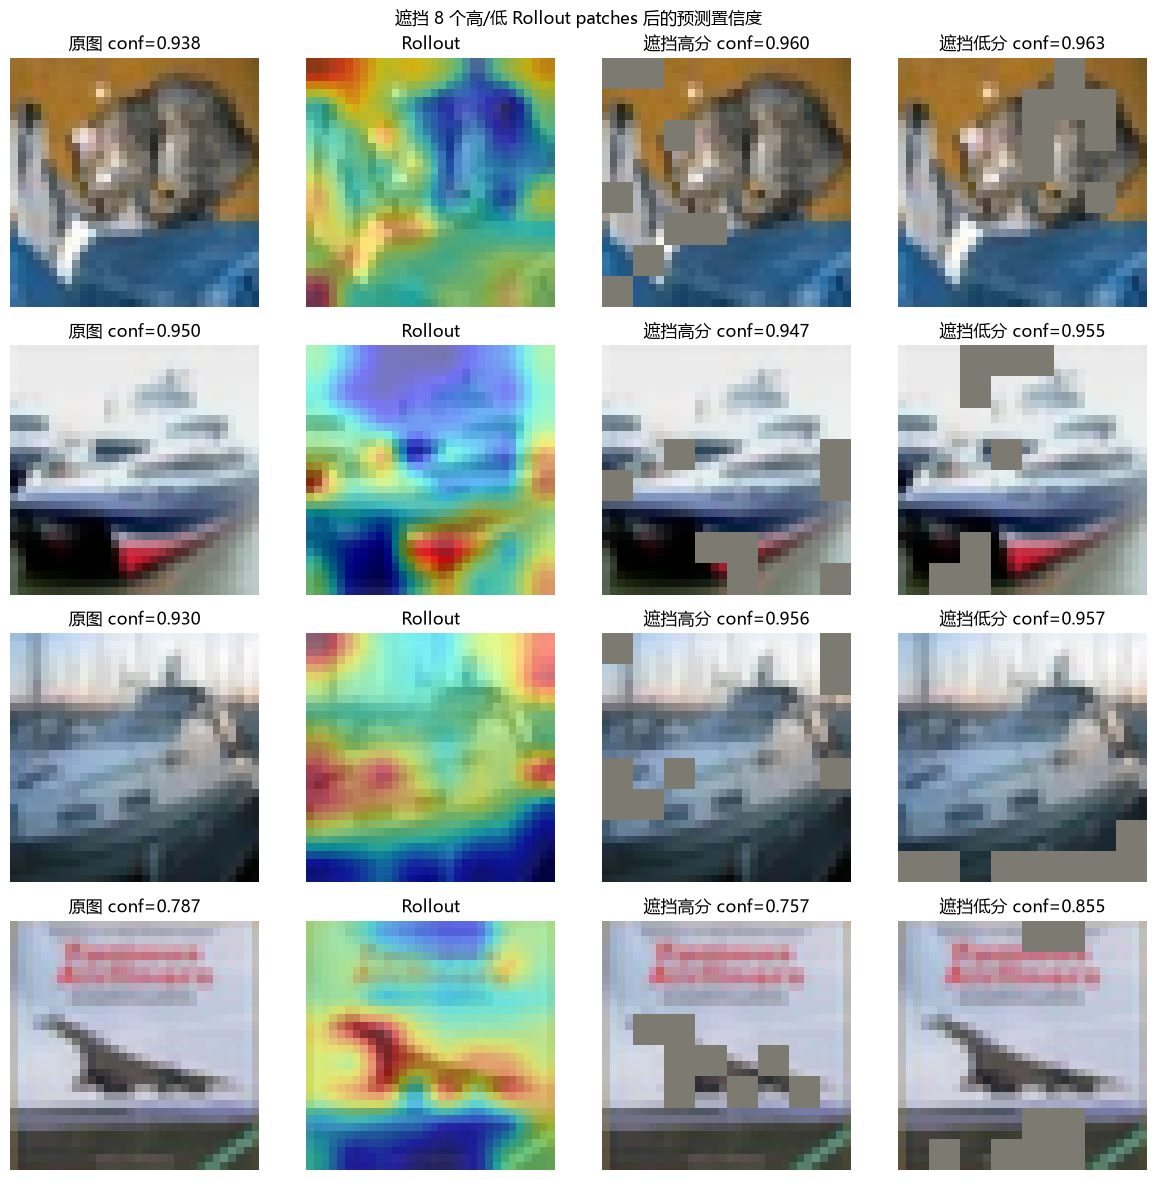

In [7]:
def mask_patches(images, patch_indices, patch_size=4):
    """将每张图片指定的 patch 设为 0；indices shape 为 BxK。"""
    masked = images.clone()
    for batch_index in range(images.shape[0]):
        for patch_index in patch_indices[batch_index].tolist():
            row, column = divmod(patch_index, 8)
            masked[
                batch_index, :,
                row * patch_size:(row + 1) * patch_size,
                column * patch_size:(column + 1) * patch_size,
            ] = 0.0
    return masked

num_masked_patches = 8
top_indices = rollout_scores.topk(num_masked_patches, dim=-1).indices
bottom_indices = rollout_scores.topk(num_masked_patches, dim=-1, largest=False).indices
top_masked = mask_patches(images, top_indices)
bottom_masked = mask_patches(images, bottom_indices)

with torch.inference_mode():
    base_probabilities = model(images).softmax(dim=-1)
    top_probabilities = model(top_masked).softmax(dim=-1)
    bottom_probabilities = model(bottom_masked).softmax(dim=-1)

base_confidence = base_probabilities.gather(1, predictions[:, None])[:, 0]
top_confidence = top_probabilities.gather(1, predictions[:, None])[:, 0]
bottom_confidence = bottom_probabilities.gather(1, predictions[:, None])[:, 0]
top_drop = base_confidence - top_confidence
bottom_drop = base_confidence - bottom_confidence

print("原类别置信度变化（正数表示下降）：")
for row in range(4):
    print(
        f"{test_dataset.classes[predictions[row].item()]:10s} "
        f"原始={base_confidence[row]:.3f}  "
        f"遮挡高分={top_confidence[row]:.3f} (下降 {top_drop[row]:+.3f})  "
        f"遮挡低分={bottom_confidence[row]:.3f} (下降 {bottom_drop[row]:+.3f})"
    )
print(f"\n平均下降：高分 patches={top_drop.mean():+.3f}，低分 patches={bottom_drop.mean():+.3f}")

top_display = (top_masked.cpu() * std + mean).clamp(0, 1)
bottom_display = (bottom_masked.cpu() * std + mean).clamp(0, 1)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for row in range(4):
    original = display_images[row].permute(1, 2, 0)
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"原图 conf={base_confidence[row]:.3f}")
    axes[row, 1].imshow(original)
    axes[row, 1].imshow(rollout_maps[row], cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Rollout")
    axes[row, 2].imshow(top_display[row].permute(1, 2, 0))
    axes[row, 2].set_title(f"遮挡高分 conf={top_confidence[row]:.3f}")
    axes[row, 3].imshow(bottom_display[row].permute(1, 2, 0))
    axes[row, 3].set_title(f"遮挡低分 conf={bottom_confidence[row]:.3f}")
    for axis in axes[row]:
        axis.axis("off")
plt.suptitle("遮挡 8 个高/低 Rollout patches 后的预测置信度")
plt.tight_layout()
display(fig)
plt.close(fig)

### 本次 4 张图片的实际结果

- 遮挡高分 patches 后，原类别置信度平均变化为 `-0.004`；
- 遮挡低分 patches 后，原类别置信度平均变化为 `-0.031`；
- 负数表示遮挡后置信度反而上升。

虽然两组平均值都没有出现绝对下降，但 4 张图片中，高分遮挡都比对应的低分遮挡更不利：它造成的置信度提升更少，或者造成了真正下降。airplane 样本最明显，高分遮挡使置信度下降 `0.030`，低分遮挡却使置信度上升 `0.068`。

因此这组小实验支持的是一个较弱但诚实的结论：**Rollout 的相对排序与模型响应存在一定一致性，但热力图不是充分的因果解释。**

## 9. 怎样解释遮挡结果

不要只看某一个样本。更合理的读法是：

1. 先比较同一张图的高分遮挡与低分遮挡；
2. 再看 4 张图片的平均置信度下降；
3. 检查遮挡后预测类别是否变化；
4. 若结果不符合预期，把它视为对解释方法的提醒，而不是修改数据来迎合结论。

严格评估通常需要更多样本、多个遮挡比例，并绘制删除曲线或插入曲线。本课先掌握最核心的验证思路。

## 10. Rollout 的局限

Attention Rollout 比单层热力图更完整，但仍有明显简化：

- 直接平均多个 head，忽略 head 的不同作用；
- 只组合注意力权重，没有考虑 Value 向量大小；
- 没有建模 MLP 和 LayerNorm 对特征的改变；
- 把残差与 Attention 简单视作相同权重；
- 结果不是类别特定的，同一张图对不同类别使用同一 Rollout。

因此它适合观察 token 信息路径，不适合被描述成完整、严格的预测原因。

## 11. 本课总结

1. Raw Attention 是单层直接连接，Rollout 是跨层累计连接；
2. 加单位矩阵是为了近似残差连接中的自信息保留；
3. 六层累计顺序为 $\tilde A_6 \cdots \tilde A_2 \tilde A_1$；
4. 最终读取 Rollout 矩阵的 CLS 行和 64 个 patch 列；
5. 遮挡实验通过真正修改输入，检查热力图与模型响应是否一致；
6. Rollout 仍是近似解释，不能替代严格的因果分析。

至此，TinyViT 已完成结构、训练、评估、源码对照和可解释性实践。按学习路线，下一阶段可以正式进入 **Swin Transformer 预训练推理与分层结构**。

## 12. 自测问题

1. 为什么最后一层 Attention 不能代表前 5 层的全部路径？
2. Rollout 中加入单位矩阵对应模型里的什么结构？
3. 为什么累计两层时是 $A_2A_1$ 而不是 $A_1A_2$？
4. `rollout[:, -1, 0, 1:]` 各个索引表示什么？
5. 遮挡高分 patch 后置信度一定下降更多吗？为什么？
6. Attention Rollout 为什么不是类别特定的？
7. Rollout 忽略了 Transformer 中哪些计算？